In [ ]:
!pip install shap --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'gol': '#e63946', 'no_gol': '#457b9d', 'neutral': '#2E4057'}

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


Se importan las librerías de análisis, visualización e interpretabilidad (SHAP, curva de calibración). Se deja listo el entorno para esta fase.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/TFM_xG/'

X_train = pd.read_csv(ruta + 'X_train.csv')
X_val   = pd.read_csv(ruta + 'X_val.csv')
X_test  = pd.read_csv(ruta + 'X_test.csv')
y_train = pd.read_csv(ruta + 'y_train.csv').squeeze()
y_val   = pd.read_csv(ruta + 'y_val.csv').squeeze()
y_test  = pd.read_csv(ruta + 'y_test.csv').squeeze()

with open(ruta + 'features.pkl', 'rb') as f:
    features = pickle.load(f)

with open(ruta + 'mejor_modelo.pkl', 'rb') as f:
    modelo = pickle.load(f)

with open(ruta + 'mejor_modelo_nombre.pkl', 'rb') as f:
    mejor_nombre = pickle.load(f)

print(f'Modelo cargado: {mejor_nombre}')
print(f'Features: {len(features)} variables predictoras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo cargado: Regresion Logistica
Features: 14 variables predictoras


Se obtiene desde Drive el modelo que ya se entrenó, que es una regresión logística, y también los conjuntos de datos para train/val/test. Se verifica que todo esté disponible y que contienen las 14 variables que se usan para hacer las predicciones.

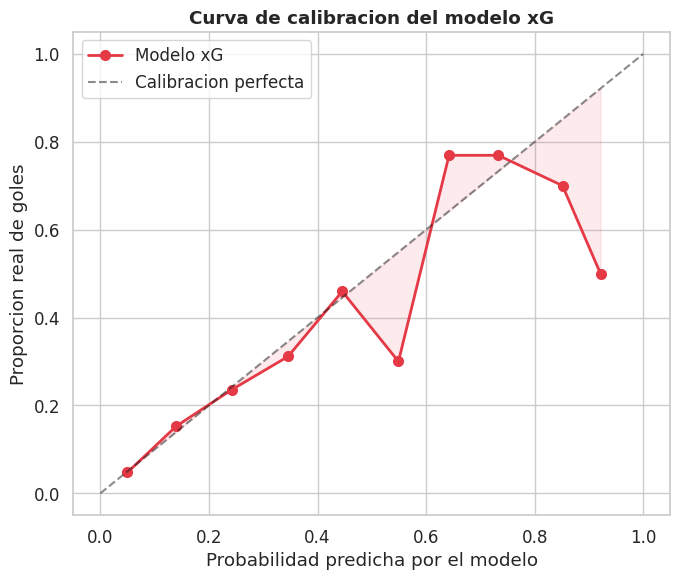

Grafico guardado como curva_calibracion.png


In [ ]:
y_prob_test = modelo.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(prob_pred, prob_true, 'o-', color=COLORS['gol'],
        linewidth=2, markersize=7, label='Modelo xG')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibracion perfecta')
ax.fill_between(prob_pred, prob_true, prob_pred,
                alpha=0.1, color=COLORS['gol'])
ax.set_xlabel('Probabilidad predicha por el modelo')
ax.set_ylabel('Proporcion real de goles')
ax.set_title('Curva de calibracion del modelo xG', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(ruta + 'curva_calibracion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como curva_calibracion.png')

Se revisa si las probabilidades que da el modelo son realistas, es decir, si cuando indica un 20% de posibilidad de que suceda algo, eso realmente pasa en el 20% de las veces. Los resultados muestran que el modelo está bastante ajustado a la realidad, muy cerca de la situación ideal, lo que demuestra que se puede confiar en él en la práctica.

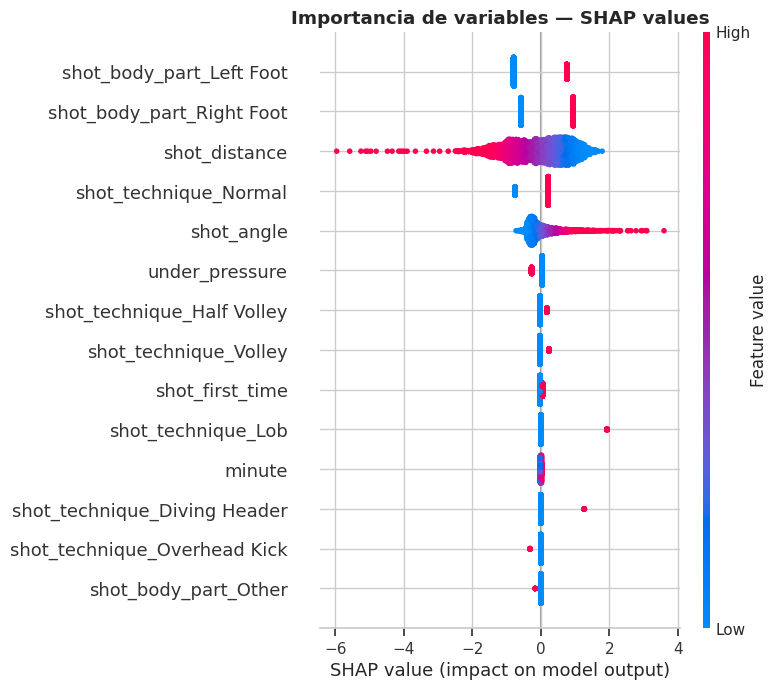

Grafico guardado como shap_summary.png


In [ ]:
explainer = shap.LinearExplainer(modelo, X_train)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  show=False)
plt.title('Importancia de variables — SHAP values', fontweight='bold')
plt.tight_layout()
plt.savefig(ruta + 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como shap_summary.png')

Se determina cuánto aporta cada dato a la predicción de manera individual usando una técnica llamada SHAP. Luego, se crea un gráfico que muestra qué variables tienen más influencia en las predicciones y si hacen que los resultados sean mayores o menores en el grupo de pruebas.

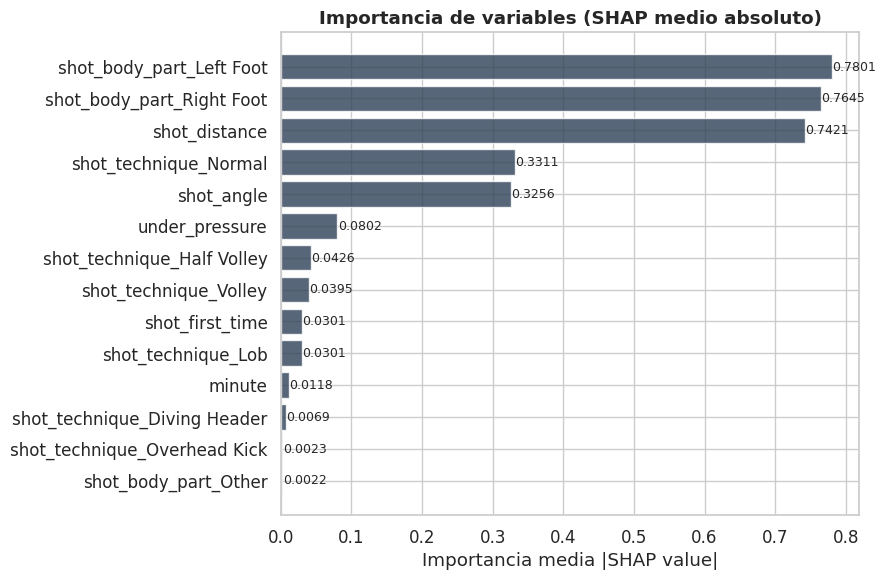

Top 5 variables mas influyentes:
                 variable  importancia_media
               shot_angle           0.325575
    shot_technique_Normal           0.331057
            shot_distance           0.742084
shot_body_part_Right Foot           0.764518
 shot_body_part_Left Foot           0.780054


In [ ]:
shap_importance = pd.DataFrame({
    'variable': features,
    'importancia_media': np.abs(shap_values).mean(axis=0)
}).sort_values('importancia_media', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(shap_importance['variable'],
               shap_importance['importancia_media'],
               color=COLORS['neutral'], alpha=0.8, edgecolor='white')
ax.set_xlabel('Importancia media |SHAP value|')
ax.set_title('Importancia de variables (SHAP medio absoluto)', fontweight='bold')
for bar, val in zip(bars, shap_importance['importancia_media']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(ruta + 'shap_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variables mas influyentes:')
print(shap_importance.tail(5)[['variable','importancia_media']].to_string(index=False))

Se explica de manera sencilla cómo afecta cada variable en general. Las que tienen mayor influencia son la parte del cuerpo que se usa (pie izquierdo o derecho), la distancia hasta el lugar donde se realiza el disparo, la técnica utilizada y el ángulo del disparo.

In [ ]:
idx_max_xg = np.argmax(y_prob_test)
idx_min_xg = np.argmin(y_prob_test)

print('Disparo con mayor xG predicho:')
print(f'  xG predicho: {y_prob_test[idx_max_xg]:.4f}')
print(f'  Resultado real: {"GOL" if y_test.iloc[idx_max_xg] == 1 else "No gol"}')
print(f'  Variables:')
print(X_test.iloc[idx_max_xg][['shot_distance','shot_angle',
                                'under_pressure','shot_first_time']].to_string())

print(f'\nDisparo con menor xG predicho:')
print(f'  xG predicho: {y_prob_test[idx_min_xg]:.4f}')
print(f'  Resultado real: {"GOL" if y_test.iloc[idx_min_xg] == 1 else "No gol"}')
print(f'  Variables:')
print(X_test.iloc[idx_min_xg][['shot_distance','shot_angle',
                                'under_pressure','shot_first_time']].to_string())

Disparo con mayor xG predicho:
  xG predicho: 0.9401
  Resultado real: GOL
  Variables:
shot_distance        3.162278
shot_angle         126.869893
under_pressure       0.000000
shot_first_time      1.000000

Disparo con menor xG predicho:
  xG predicho: 0.0002
  Resultado real: No gol
  Variables:
shot_distance      74.426339
shot_angle          5.641483
under_pressure      0.000000
shot_first_time     0.000000


Se analiza en detalle el disparo con la mayor y la menor probabilidad de ser gol que se predijeron en la prueba. El disparo con mayor probabilidad (0.94) resultó ser gol, ya que fue chutado muy cerca y con un buen ángulo. Por otro lado, el disparo con la menor probabilidad (0.0002) no fue gol, ya que fue desde muy lejos y con un ángulo muy cerrado. Esto muestra claramente que el modelo entiende bien lo difícil que es cada oportunidad de marcar.

In [ ]:
df_negocio = pd.read_csv(ruta + 'dataset_xg_transfermarkt.csv')

print(f'Jugadores disponibles para analisis de negocio: {len(df_negocio)}')
print(df_negocio.columns.tolist())
print(df_negocio.head())

Jugadores disponibles para analisis de negocio: 39
['player_name', 'n_disparos', 'goles_reales', 'xg_acumulado', 'xg_por_disparo', 'player_id', 'market_value_eur', 'market_value_M', 'eficiencia']
           player_name  n_disparos  goles_reales  xg_acumulado  \
0            Adil Rami          20             0      1.905894   
1  Aleksandar Mitrović          26             3      3.763395   
2    Antoine Griezmann         255            42     36.474054   
3           Arda Turan          22             4      3.567312   
4         Arjen Robben          31             2      2.334643   

   xg_por_disparo  player_id  market_value_eur  market_value_M  eficiencia  
0        0.095295      51118            250000            0.25    0.000000  
1        0.144746      51152          10000000           10.00    0.797152  
2        0.143036     125781           8000000            8.00    1.151503  
3        0.162151      21369            100000            0.10    1.121293  
4        0.075311     

Se carga el dataset ya cruzado entre el xG generado por cada jugador y su valor de mercado. Finalmente quedan disponibles 39 jugadores con datos suficientes para el análisis de negocio.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_negocio[['xg_norm', 'valor_norm']] = scaler.fit_transform(
    df_negocio[['xg_acumulado', 'market_value_M']]
)

df_negocio['infravaloracion'] = df_negocio['xg_norm'] - df_negocio['valor_norm']


print('TOP 10 JUGADORES INFRAVALORADOS (alto xG, bajo valor de mercado):')
top_infra = df_negocio.nlargest(10, 'infravaloracion')[
    ['player_name', 'n_disparos', 'goles_reales',
     'xg_acumulado', 'market_value_M', 'infravaloracion']
]
print(top_infra.to_string(index=False))

print('\nTOP 10 JUGADORES SOBREVALORADOS (bajo xG, alto valor de mercado):')
top_sobre = df_negocio.nsmallest(10, 'infravaloracion')[
    ['player_name', 'n_disparos', 'goles_reales',
     'xg_acumulado', 'market_value_M', 'infravaloracion']
]
print(top_sobre.to_string(index=False))

TOP 10 JUGADORES INFRAVALORADOS (alto xG, bajo valor de mercado):
       player_name  n_disparos  goles_reales  xg_acumulado  market_value_M  infravaloracion
 Antoine Griezmann         255            42     36.474054           8.000         0.920921
     Karim Benzema         157            31     25.202437           5.000         0.635982
Zlatan Ibrahimović          82            13     10.531066           2.000         0.256042
    Cédric Bakambu          52            13      9.716121           1.200         0.241278
     Ludovic Giuly          37             6      6.513558           0.400         0.159795
     John Guidetti          34             7      5.575811           0.600         0.131589
    Giuseppe Rossi          41             5      4.581053           0.100         0.108797
       Daniel Wass          53             2      4.482860           0.400         0.103050
    Olivier Giroud          32             4      4.543691           0.900         0.099745
      Takashi 

Se ajustan los datos del xG acumulado y del valor de mercado para poder compararlos fácilmente. Se crea un índice que ayuda a identificar a los jugadores que están infravalorados (los que crean muchas amenazas pero tienen un valor bajo, como Griezmann o Benzema) y a los que están sobrevalorados (los que valen mucho pero generan poca ayuda, como Dembélé o Kane).

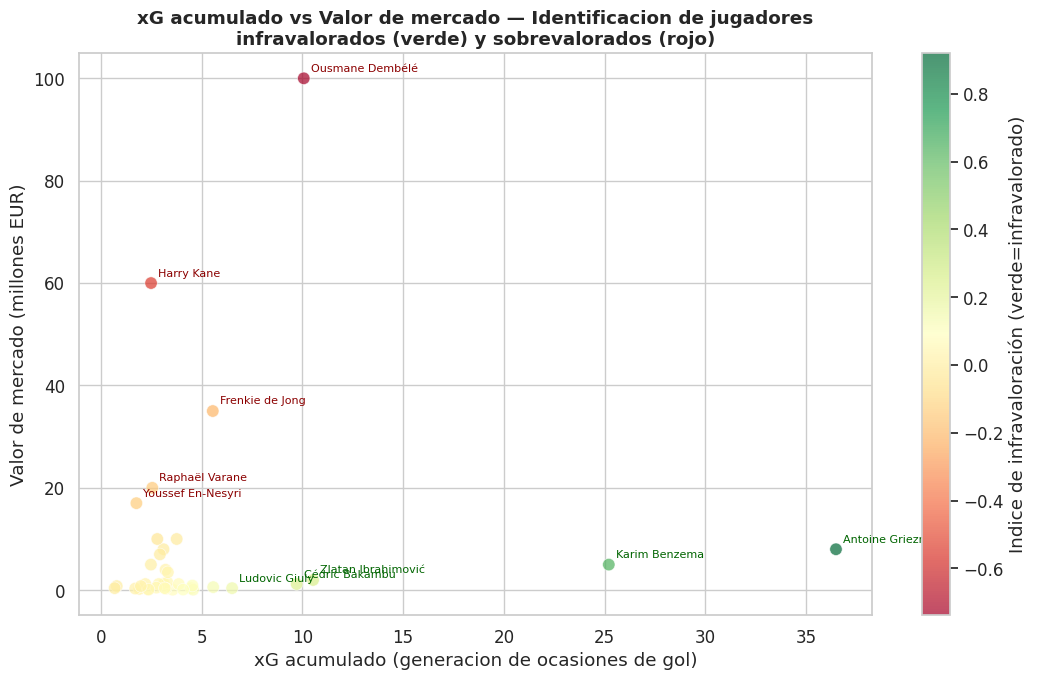

Grafico guardado como xg_vs_valor_mercado.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    df_negocio['xg_acumulado'],
    df_negocio['market_value_M'],
    c=df_negocio['infravaloracion'],
    cmap='RdYlGn', s=80, alpha=0.7, edgecolors='white', linewidth=0.5
)

for _, row in df_negocio.nlargest(5, 'infravaloracion').iterrows():
    ax.annotate(row['player_name'],
                (row['xg_acumulado'], row['market_value_M']),
                fontsize=8, color='darkgreen',
                xytext=(5, 5), textcoords='offset points')

for _, row in df_negocio.nsmallest(5, 'infravaloracion').iterrows():
    ax.annotate(row['player_name'],
                (row['xg_acumulado'], row['market_value_M']),
                fontsize=8, color='darkred',
                xytext=(5, 5), textcoords='offset points')

plt.colorbar(scatter, label='Indice de infravaloración (verde=infravalorado)')
ax.set_xlabel('xG acumulado (generacion de ocasiones de gol)')
ax.set_ylabel('Valor de mercado (millones EUR)')
ax.set_title('xG acumulado vs Valor de mercado — Identificacion de jugadores\ninfravalorados (verde) y sobrevalorados (rojo)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(ruta + 'xg_vs_valor_mercado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como xg_vs_valor_mercado.png')

Se muestra cómo se relacionan las posibilidades de marcar un gol que un jugador genera con su valor en el mercado. Los jugadores que están muy por debajo de lo que valdrían (sobrevalorados) se resaltan en rojo, y los que están por encima de su valor (infravalorados) en verde. Esto puede ser útil para un equipo que busca nuevos jugadores para su club.

In [ ]:
df_negocio.to_csv(ruta + 'dataset_negocio_final.csv', index=False)
print('Dataset guardado como dataset_negocio_final.csv')
print('Listo para el notebook 05_productivizacion.ipynb')

Dataset guardado como dataset_negocio_final.csv
Listo para el notebook 05_productivizacion.ipynb


Se guarda el dataset y se deja listo para la fase de productivización (notebook 05).